In [33]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [34]:
# Load embeddings and labels
X = np.load("embeddings.npy")  # Features (embeddings)
y = np.load("labels.npy")      # Labels

# Print shape to verify
print("Feature matrix shape:", X.shape)  # (num_samples, embedding_dim)
print("Labels shape:", y.shape)          # (num_samples,)

Feature matrix shape: (27764, 768)
Labels shape: (27764,)


In [ ]:
print("First sample (first 10 features):", X[0][:10])  # View first 10 values
print("Number of features per sample:", X.shape[1])

First sample (first 10 features): [-1.7398922e+00  4.8072690e-01  2.9929407e-04  2.1737516e+00
 -1.8970181e+00 -2.1639594e-01 -2.9107076e-01  1.6447483e-01
  1.9824045e+00  2.4760237e+00]
Number of features per sample: 768


In [36]:
# Split into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}, Test data shape: {X_test.shape}")

Training data shape: (22211, 768), Test data shape: (5553, 768)


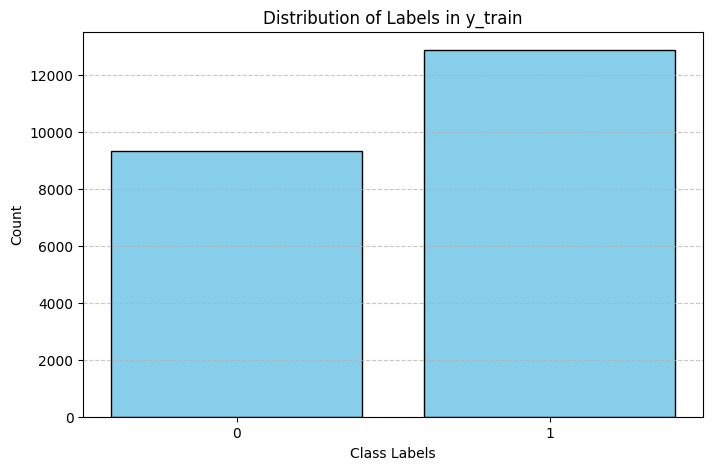

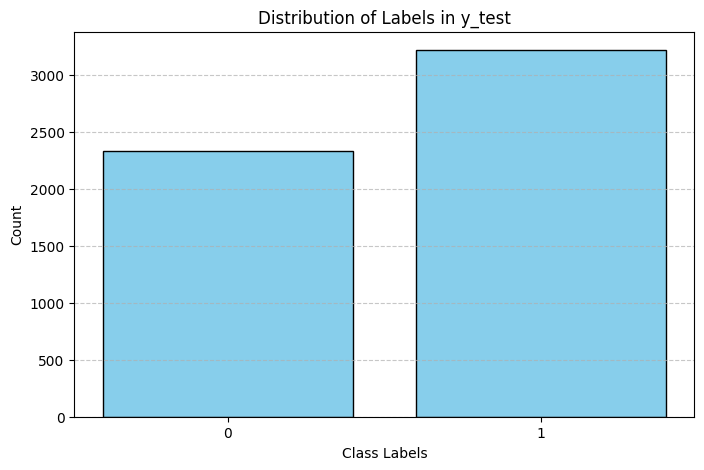

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Count occurrences of each class
classes, counts = np.unique(y_train, return_counts=True)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color='skyblue', edgecolor='black')

# Labels and title
plt.xlabel('Class Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels in y_train')
plt.xticks(classes)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Count occurrences of each class
classes, counts = np.unique(y_test, return_counts=True)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color='skyblue', edgecolor='black')

# Labels and title
plt.xlabel('Class Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels in y_test')
plt.xticks(classes)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [38]:
# Print the number of features per sample
print("Number of features per sample:", X_train.shape[1])

Number of features per sample: 768


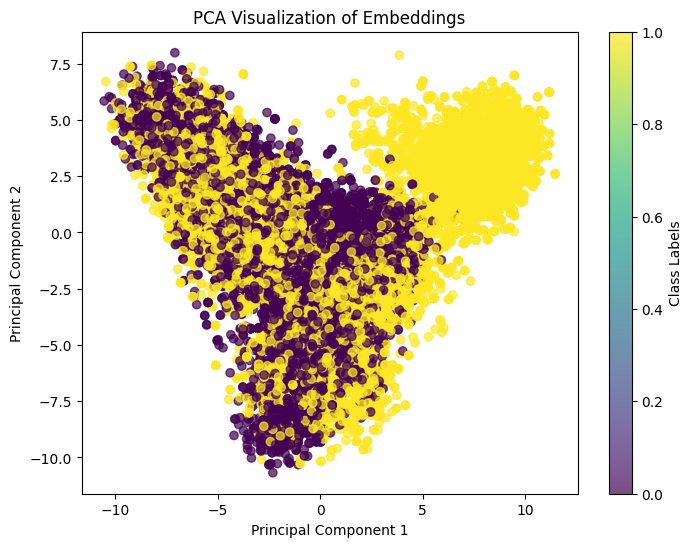

In [39]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# Scatter plot of PCA-reduced features
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Class Labels")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Embeddings")
plt.show()

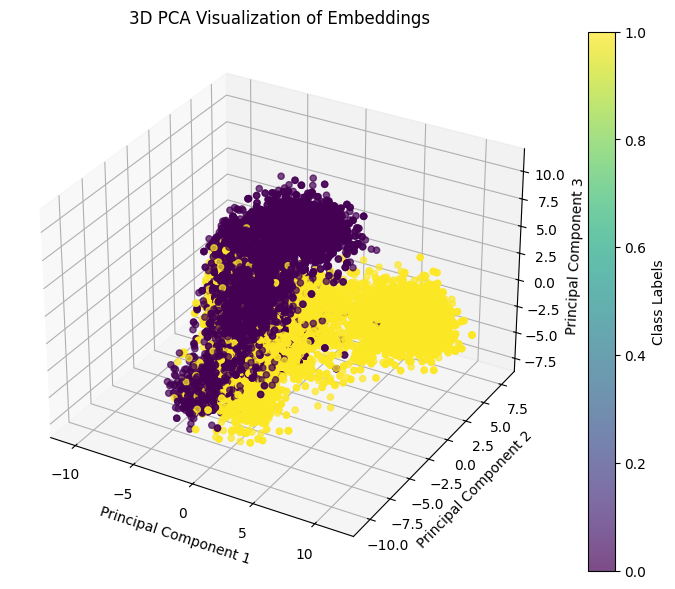

In [40]:
# Apply PCA to reduce to 3 dimensions
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train)

# 3D Scatter plot of PCA-reduced features
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y_train, cmap='viridis', alpha=0.7)

# Labels and color bar
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA Visualization of Embeddings")
plt.colorbar(scatter, label="Class Labels")

# Show plot
plt.show()

In [ ]:
# Initialize SVM classifier with linear kernel
svm_model = SVC(kernel="linear", C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train, y_train)


SVC(kernel='linear', random_state=42)

In [43]:
# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Print detailed classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.990815775256618
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2334
           1       0.99      0.99      0.99      3219

    accuracy                           0.99      5553
   macro avg       0.99      0.99      0.99      5553
weighted avg       0.99      0.99      0.99      5553



Text(0.5, 1.0, 'Confusion Matrix')

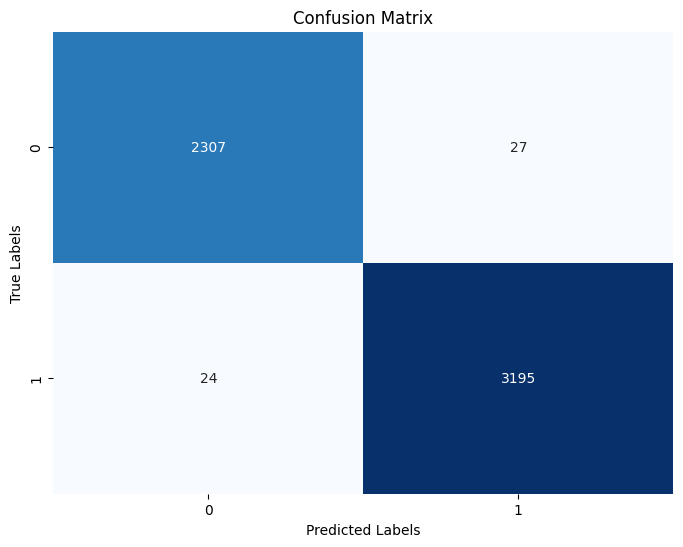

In [45]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')


In [47]:
# Run svm again, but everytime with only one of the 768 features
accuracies = []

for i in range(X_train.shape[1]):
    # Select only one feature
    X_train_single = X_train[:, i].reshape(-1, 1)
    X_test_single = X_test[:, i].reshape(-1, 1)

    # Initialize SVM classifier
    svm_model = SVC(kernel="linear", C=1.0, random_state=42)

    # Train the model
    print(f"Training model with feature {i}")
    svm_model.fit(X_train_single, y_train)

    # Make predictions
    y_pred = svm_model.predict(X_test_single)

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Feature {i}: Accuracy: {accuracy}")
    accuracies.append(accuracy)

# Get the feature with the highest accuracy
best_feature = np.argmax(accuracies)
best_accuracy = accuracies[best_feature]

print(f"Best feature: {best_feature}, Accuracy: {best_accuracy}")

Training model with feature 0
Feature 0: Accuracy: 0.5796866558616964
Training model with feature 1
Feature 1: Accuracy: 0.5796866558616964
Training model with feature 2
Feature 2: Accuracy: 0.5796866558616964
Training model with feature 3
Feature 3: Accuracy: 0.5796866558616964
Training model with feature 4
Feature 4: Accuracy: 0.5796866558616964
Training model with feature 5
Feature 5: Accuracy: 0.5796866558616964
Training model with feature 6
Feature 6: Accuracy: 0.5796866558616964
Training model with feature 7
Feature 7: Accuracy: 0.5796866558616964
Training model with feature 8
Feature 8: Accuracy: 0.5796866558616964
Training model with feature 9
Feature 9: Accuracy: 0.5796866558616964
Training model with feature 10
Feature 10: Accuracy: 0.5796866558616964
Training model with feature 11
Feature 11: Accuracy: 0.5796866558616964
Training model with feature 12
Feature 12: Accuracy: 0.5796866558616964
Training model with feature 13
Feature 13: Accuracy: 0.5796866558616964
Training mod

In [49]:
# Get the 5 best features
top_features = np.argsort(accuracies)[::-1][:5]
top_accuracies = [accuracies[i] for i in top_features]

print(f"Top 5 features: {top_features}, Accuracies: {top_accuracies}")

Top 5 features: [563 494 646 570 246], Accuracies: [0.6529803709706465, 0.6389339095984152, 0.63713308121736, 0.634431838645777, 0.634071672969566]


In [ ]:
# Run SVM with the best features
X_train_best = X_train[:, best_feature].reshape(-1, 1)
X_test_best = X_test[:, best_feature].reshape(-1, 1)

# Initialize SVM classifier
svm_model = SVC(kernel="linear", C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train_best, y_train)

# Make predictions
y_pred = svm_model.predict(X_test_best)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)

print(f"accuracy with best features: {accuracy}")

accuracy with best features: 0.6529803709706465


In [51]:
# Run SVM with all but the best features
X_train_other = np.delete(X_train, best_feature, axis=1)
X_test_other = np.delete(X_test, best_feature, axis=1)

# Initialize SVM classifier
svm_model = SVC(kernel="linear", C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train_other, y_train)

# Make predictions
y_pred = svm_model.predict(X_test_other)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)

print(f"accuracy without best features: {accuracy}")

accuracy without best features: 0.9902755267423015
